# Dask Exercise 1: switching from `pandas`

**Dask intro**
* [Why Dask?](https://docs.dask.org/en/stable/why.html)
* [10 min to Dask](https://docs.dask.org/en/stable/10-minutes-to-dask.html)
* [Dask dataframe](https://docs.dask.org/en/stable/dataframe.html) -- scope of what is easily ported from `pandas` vs what might be slow / not implemented in Dask.
* [Dask and parquets](https://docs.dask.org/en/stable/dataframe-parquet.html)
* [Dask tutorial](https://tutorial.dask.org/01_dataframe.html) on dataframes

The first and easiest step in starting to use `dask` is to make the switch from `pandas` dataframes (dfs) to `dask` dataframes (ddfs) and find the equivalent methods. The look and feel of this should be very familiar.

The **major** difference between `pandas` dfs and `dask` ddfs is that ddfs are not read into memory. The schema and certain attributes of the df are there, but to actually get computations, you have call `.compute()`. Dask uses a lazy evaluation, which means it's storing the steps and the order you want to do it in, and evaluating it all at once when you say you want it.

|  current    | dask |    
|-------------|-----------------------|
| pandas      | dask dataframes       | 
| numpy       | dask arrays           |
| delayed     | general; loops        |


Skills:
* equivalent methods for dask dataframes
* task graphs
* concatenation
* merges
* partitioned parquets

In [1]:
import dask.dataframe as dd
import dask_geopandas as dg
import geopandas as gpd
import pandas as pd

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

TAXI_DATA = ("https://raw.githubusercontent.com/mwaskom/"
             "seaborn-data/master/taxis.csv"
            )

/opt/conda/lib/python3.9/site-packages/geopandas/_compat.py:123: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/dask_geopandas/backends.py:13: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/l

### Basics

Most `pandas` methods can be called, but you need to add a `.compute()`.

To convert a ddf to a df, simply use `ddf.compute()`. 

Alternatively, you can change any df to a ddf.

In [2]:
df = pd.read_csv(TAXI_DATA)

ddf = dd.from_pandas(df, npartitions=1)

In [3]:
ddf = dd.read_csv(TAXI_DATA)
ddf

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
npartitions=1,,,,,,,,,,,,,,
,object,object,int64,float64,float64,float64,float64,float64,object,object,object,object,object,object
,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [4]:
len(ddf)

6433

In [5]:
ddf.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [6]:
ddf.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

In [8]:
ddf.describe().compute()

,passengers,distance,fare,tip,tolls,total
count,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
std,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570
min,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000


In [9]:
# df.shape or len(df) would not work
# to find how many rows there are, find the length of the index
len(ddf.index)

6433

### Cleaning Columns / Apply Row-Wise Functions  

For the most part, this is intact. Sometimes there is a `dask` equivalent of the `pandas` methods. Always look to see if there is one first.

In [10]:
# Lambda functions in pandas
df = df.assign(
    same_borough = df.apply(
        lambda x: 
        1 if x.pickup_borough == x.dropoff_borough
        else 0, axis=1)
)

In [11]:
# Apply the same lambda function for dask df
# Make sure to add the metadata argument to specify the data type
ddf = ddf.assign(
    same_borough = ddf.apply(
        lambda x:
        1 if x.pickup_borough == x.dropoff_borough
        else 0, axis=1, meta=('same_borough', 'int')
    )
)

In [12]:
ddf.same_borough.value_counts().compute()

1    5582
0     851
Name: same_borough, dtype: int64

In [13]:
def type_of_trip(row) -> str: 
    if ((row.passengers == 1) and 
        (row.distance >= 5) and 
        (row.pickup_borough != row.dropoff_borough)
       ):
        return "individual_long_trips"
    elif ((row.passengers > 1) and 
          (row.distance >= 5) and 
          (row.pickup_borough != row.dropoff_borough)
    ):
        return "group_long_trips"
    
    else:
        return "short_trips"
        

In [14]:
ddf = ddf.assign(
    trip_type = ddf.apply(
        lambda x: type_of_trip(x), 
        axis=1, meta=("trip_type", "str"))
)

In [15]:
ddf.groupby("trip_type").agg(
    {"total": "sum", 
     "passengers": "sum"}).reset_index().compute()

,trip_type,total,passengers
0,short_trips,88220.44,8917
1,individual_long_trips,23164.23,482
2,group_long_trips,7740.30,503


### DateTimes

A lot of the methods are similar here!

In [16]:
ddf.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,same_borough,trip_type
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,1,short_trips
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,1,short_trips
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,1,short_trips
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,1,short_trips
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,1,short_trips


In [17]:
ddf = ddf.assign(
    pickup_time = dd.to_datetime(ddf.pickup),
    pickup_hour = dd.to_datetime(ddf.pickup).dt.hour
)

In [18]:
ddf.pickup_hour.value_counts().compute()

18    417
19    406
17    388
20    368
14    360
21    355
16    336
12    334
15    330
10    325
22    321
9     319
13    316
8     313
23    296
11    295
7     221
0     205
6     142
1     110
2     101
3      67
4      57
5      51
Name: pickup_hour, dtype: int64

## Task Graphs

Since Dask is lazily evaluated, it's really just storing the order of operations for you. To see all the transformations you're doing to the dataframe, look at the task graph.

In [19]:
# Split up the ddf into multiple partitions
ddf2 = ddf.repartition(npartitions=5)

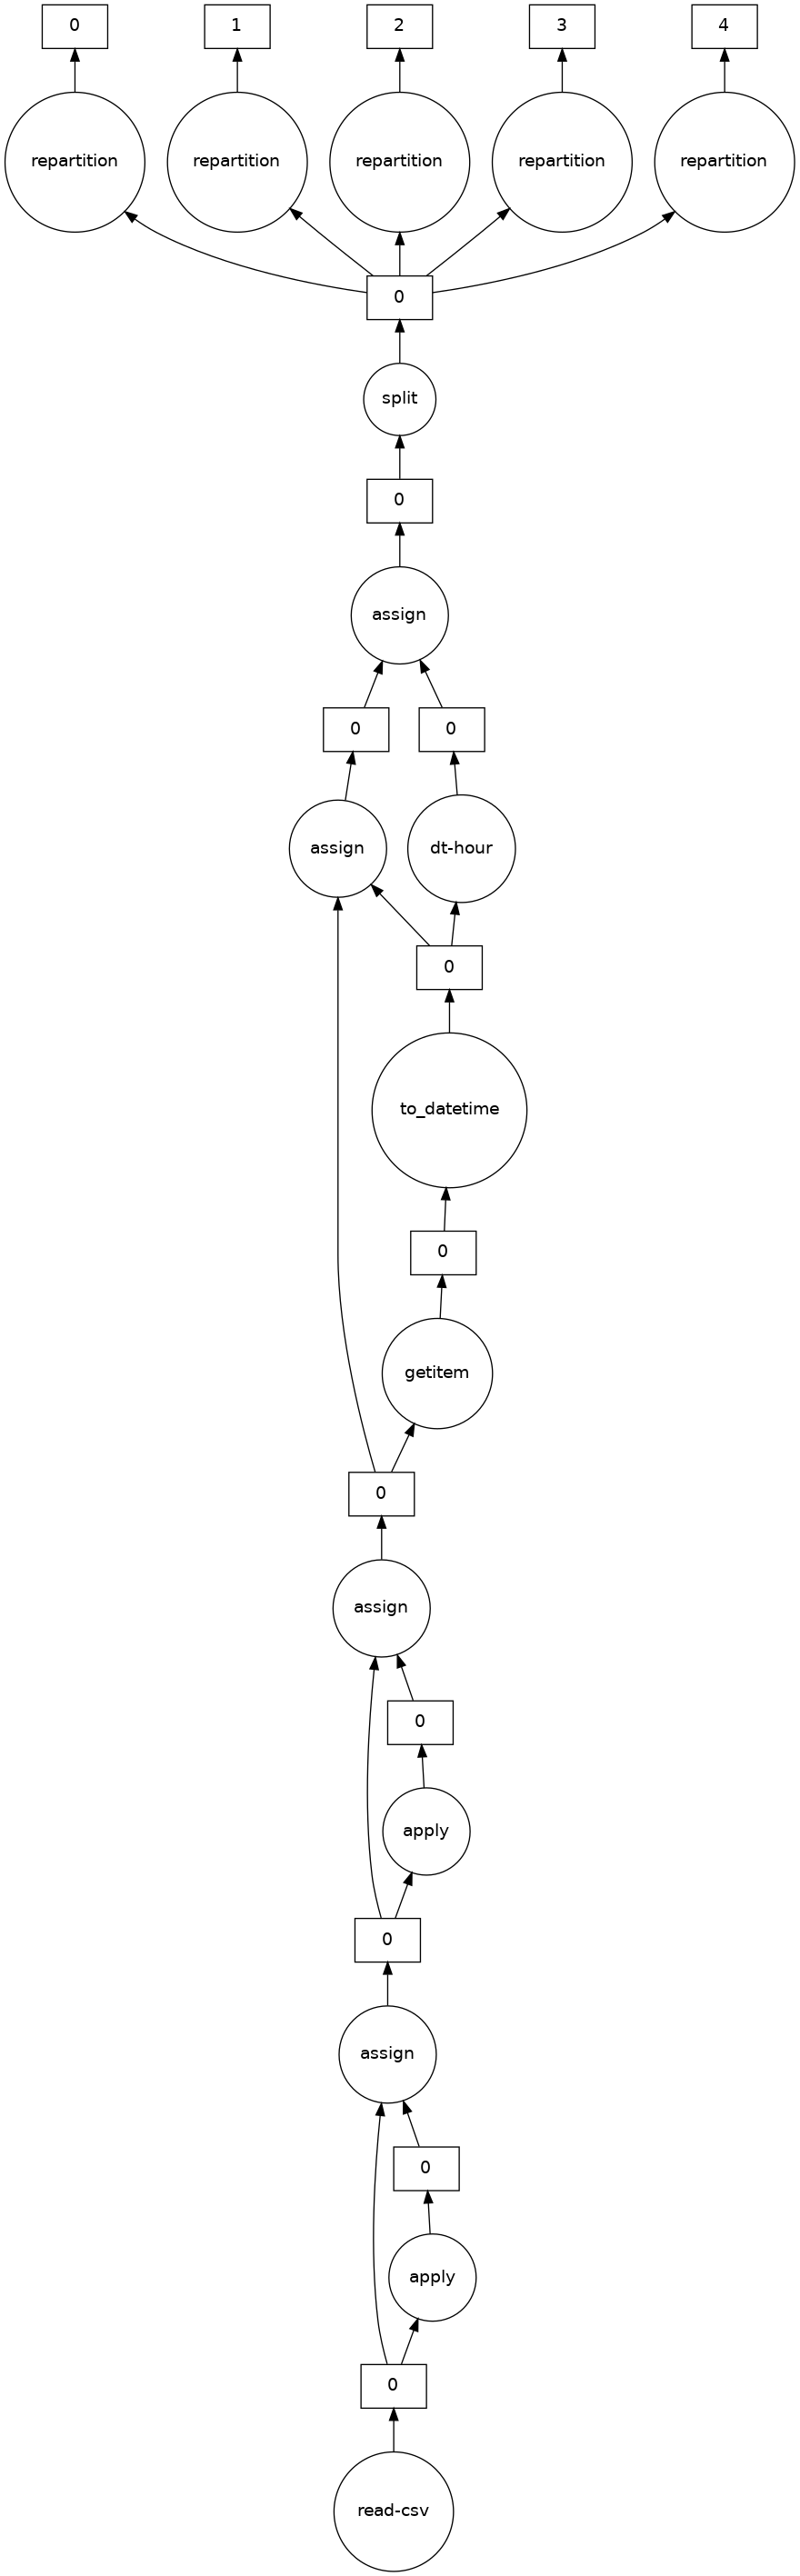

In [62]:
ddf2.visualize()

## Concatenation

Instead of `pd.concat`, use `dd.multi.concat`. [Docs](https://docs.dask.org/en/stable/generated/dask.dataframe.multi.concat.html).

The fact that we are concatenating a list of dfs or ddfs is a very useful concept to use in `dask.delayed`.

In [21]:
yellow = df[df.color=="yellow"].reset_index(drop=True)
green = df[df.color=="green"].reset_index(drop=True)

In [22]:
yellow.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,same_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,1
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,1
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,1
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,1
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,1


In [23]:
# Turning regular old dfs into ddfs
yellow_ddf = dd.from_pandas(yellow, npartitions=1)
green_ddf = dd.from_pandas(green, npartitions=1)

In [24]:
combined_df = pd.concat([yellow, green], axis=0)
combined_df.shape

(6433, 15)

In [25]:
combined_ddf = dd.multi.concat([yellow_ddf, green_ddf], axis=0)

In [26]:
len(combined_ddf)

6433

In [27]:
len(combined_ddf.index)

6433

## Merges

This isn't a very meaningful merge, but we'll use it to demonstrate anyway.

Let's say that there's a column called `manhattan_flag` in `yellow_ddf` and we want to bring that column in for `green_ddf`. 

We cannot use the `validate` parameter in the merge, but most of the other arguments are present. [Docs](https://docs.dask.org/en/stable/generated/dask.dataframe.DataFrame.merge.html).

In [28]:
# Not that this is a meaningful merge, but, we can!
yellow_ddf = yellow_ddf.assign(
    manhattan_flag = yellow_ddf.apply(
        lambda x: 
        1 if (x.pickup_borough == "Manhattan") or 
        (x.dropoff_borough=="Manhattan") 
         else 0, axis=1, meta=("manhattan_flag", "int")
    )
)

yellow_ddf


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,same_borough,manhattan_flag
npartitions=1,,,,,,,,,,,,,,,,
0,object,object,int64,float64,float64,float64,float64,float64,object,object,object,object,object,object,int64,int64
5450,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [29]:
yellow_ddf_flag = yellow_ddf[["pickup_borough", "dropoff_borough", 
                              "manhattan_flag"]].drop_duplicates()

In [30]:
# yellow_ddf_flag.visualize()

In [31]:
m1 = dd.merge(
    green_ddf,
    yellow_ddf_flag,
    on = ["pickup_borough", "dropoff_borough"],
    how = "inner"
)

In [32]:
m1.manhattan_flag.value_counts().compute()

0    600
1    378
Name: manhattan_flag, dtype: int64

## Partitioned Parquets

We already use parquets because it's a lot faster than csv or geojson. We can also use partitioned parquets (a folder of lots of smaller parquet files).

The folder of partitioned parquets can be easily read back in or filtered against.

If you find that the `.compute()` step in bringing a very large ddf into memory is holding you back, consider exporting it out as a partitioned parquet. Reading a partitioned parquet back in and exporting as a single parquet is faster.

In [33]:
type(ddf.compute())

pandas.core.frame.DataFrame

In [34]:
type(ddf)

dask.dataframe.core.DataFrame

In [35]:
# We don't have trouble computing and bringing this back into memory
# ddf.compute()

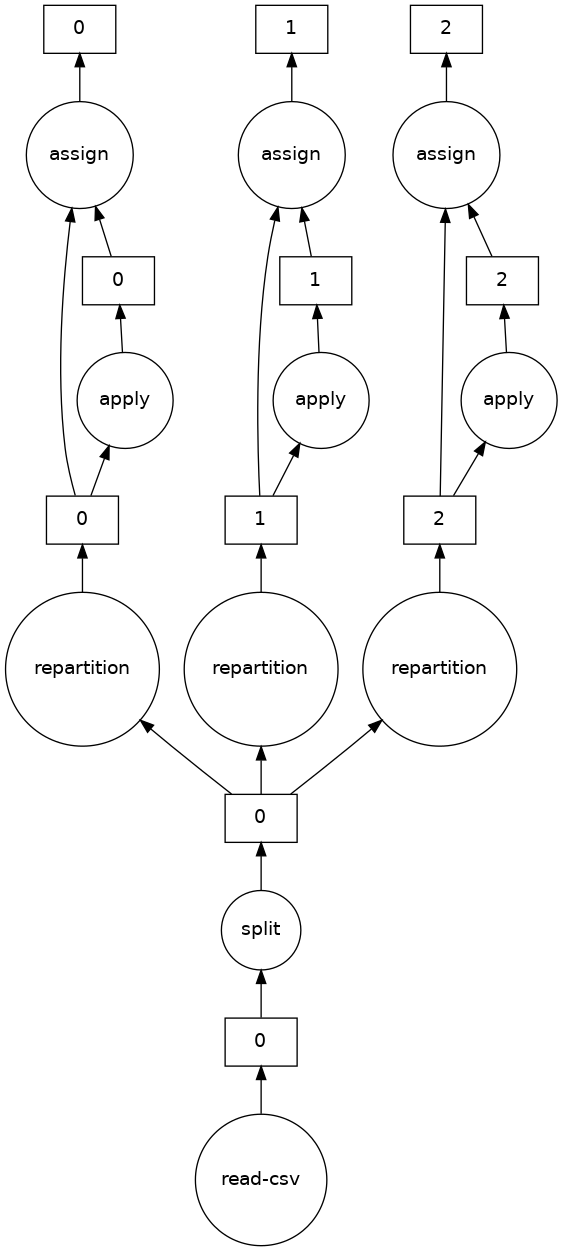

In [36]:
# Look at this task graph
ddf3 = dd.read_csv(TAXI_DATA).repartition(npartitions=3)
ddf3 = ddf3.assign(
    trip_type = ddf3.apply(
        lambda x: type_of_trip(x), 
        axis=1, meta=("trip_type", "str"))
)

ddf3.visualize()

In [37]:
ddf3.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,trip_type
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,short_trips
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,short_trips
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,short_trips
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,short_trips
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,short_trips


In [38]:
len(ddf3)

6433

In [39]:
# look at the format of this partitioned parquet
ddf3.to_parquet("dask1_multipart", overwrite=True)

In [40]:
read_in_ddf3 = dd.read_parquet("dask1_multipart/")

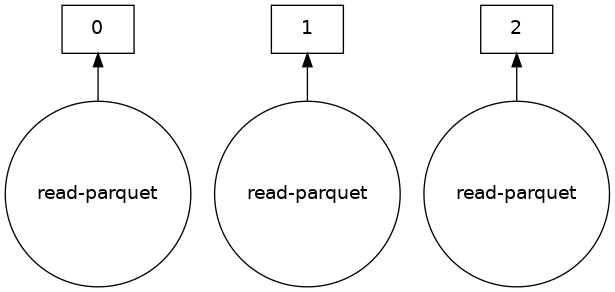

In [41]:
# task graph just reads in each part
read_in_ddf3.visualize()

In [64]:
len(read_in_ddf3)

6433

## To Do

* Import the `stop_times` parquet using dask
* Grab the hour from the `arrival_sec` column
* For an operator, calculate the number of stops per trip is occurring each hour 
* Now group the individual hours into peak and off peak periods. Use 8am-10am AM Peak and 4pm-7pm PM Peak. Combine these two peak periods into one.
* Create a table of hourly stops per trip **and** peak vs offpeak stops per trip. Only display these tables for 2 operators of your choice (subset at the end).
* Use the equivalent dask dataframe methods and only compute results in the last step.
* Show the task graph at the end

In [91]:
GCS_FILE_PATH = ("gs://calitp-analytics-data/data-analyses/"
                 "rt_delay/compiled_cached_views/"
                )

analysis_date = "2023-01-18"

stop_times = dd.read_parquet(
    f"{GCS_FILE_PATH}st_{analysis_date}.parquet")

In [92]:
stop_times.head(2)

,feed_key,trip_id,stop_id,stop_sequence,timepoint,arrival_sec,departure_sec,arrival_hour,departure_hour
0,48138ae7269d615d5509958097039bf7,t287-b194-sl4_merged_3564,1140,11,NaN,25047,25047,6,6
1,48138ae7269d615d5509958097039bf7,t708-b12D-sl4_merged_4213,1161,25,NaN,66583,66583,18,18


In [93]:
len(stop_times)

3589931

In [94]:
stop_times

,feed_key,trip_id,stop_id,stop_sequence,timepoint,arrival_sec,departure_sec,arrival_hour,departure_hour
npartitions=1,,,,,,,,,
,object,object,object,int64,float64,int64,int64,int64,int64
,...,...,...,...,...,...,...,...,...


* Grab the hour from the arrival_sec column didn't work.

In [98]:
stop_times = stop_times.assign(
    pickup_time = dd.to_datetime(stop_times.arrival_sec, unit = 's'),
    pickup_hour = dd.to_datetime(stop_times.arrival_sec, unit = 's').dt.hour
)
    

In [99]:
type(stop_times)

dask.dataframe.core.DataFrame

In [100]:
stop_times.head(2)

,feed_key,trip_id,stop_id,stop_sequence,timepoint,arrival_sec,departure_sec,arrival_hour,departure_hour,pickup_time,pickup_hour
0,48138ae7269d615d5509958097039bf7,t287-b194-sl4_merged_3564,1140,11,NaN,25047,25047,6,6,1970-01-01 06:57:27,6
1,48138ae7269d615d5509958097039bf7,t708-b12D-sl4_merged_4213,1161,25,NaN,66583,66583,18,18,1970-01-01 18:29:43,18


* For an operator, calculate the number of stops per trip is occurring each hour

In [101]:
# Testfirst
stop_times = stop_times.groupby(["feed_key","pickup_hour","trip_id"]).agg(
    {"stop_id": "count"}).rename(columns = {'stop_id':'total_stops_per_hr'}).reset_index()

In [102]:
type(stop_times)

dask.dataframe.core.DataFrame

In [103]:
stop_times.head()

,feed_key,pickup_hour,trip_id,total_stops_per_hr
0,48138ae7269d615d5509958097039bf7,6,t287-b194-sl4_merged_3564,14
1,48138ae7269d615d5509958097039bf7,18,t708-b12D-sl4_merged_4213,43
2,48138ae7269d615d5509958097039bf7,12,t476-b194-sl4_merged_4047,12
3,48138ae7269d615d5509958097039bf7,18,t6DF-b68-sl4_merged_3187,23
4,d4642902c43d526677dff02b09342b78,15,t607-b1F4B-sl2_merged_1620,4


stop_times.arrival_hour.unique().compute()

* Now group the individual hours into peak and off peak periods. Use 8am-10am AM Peak and 4pm-7pm PM Peak. Combine these two peak periods into one.

In [104]:
def peak_hours(row):
    if (8 <= row.pickup_hour <=10) or (16 <= row.pickup_hour <=19):
        return "peak"
    else:
        return "not peak"

In [105]:
stop_times['peak_hour_trips'] = stop_times.apply(lambda x: peak_hours(x),
                                           axis=1, meta = ("peak_hour_trips","str"))

In [106]:
stop_times.columns

Index(['feed_key', 'pickup_hour', 'trip_id', 'total_stops_per_hr',
       'peak_hour_trips'],
      dtype='object')

In [107]:
stop_times.feed_key.nunique().compute()

142

In [108]:
stop_times.feed_key.unique().compute()

0      48138ae7269d615d5509958097039bf7
1      d4642902c43d526677dff02b09342b78
2      e0b5f34626227db91053ff01b23358be
3      21fa0b125d801eb5058da2ec5d748bda
4      227c21ddaeb14e27fc2e6ba1076d9d5e
                     ...               
137    de81ef0560e2a6de7813a7301180e852
138    e397be6d780f75dd416fbda5024e17c7
139    f0b28ce2e70bba09a56e0b6a25268666
140    f8d3bfd9e780aa3b3ce1340b2116513f
141    fdf54bff79f705767670a13db867d3f7
Name: feed_key, Length: 142, dtype: object

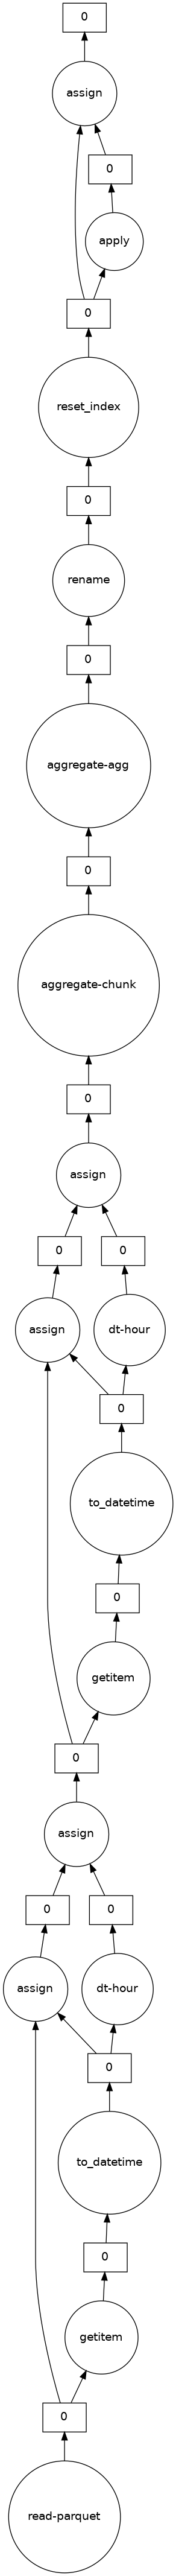

In [109]:
stop_times.visualize()

* Create a table of hourly stops per trip and peak vs offpeak stops per trip. Only display these tables for 2 operators of your choice (subset at the end).

In [110]:
# Filter for ops
two_ops = stop_times[stop_times.feed_key.isin(["48138ae7269d615d5509958097039bf7","d4642902c43d526677dff02b09342b78"])].reset_index(drop = True)

In [111]:
two_ops.feed_key.value_counts().compute()

d4642902c43d526677dff02b09342b78    782
48138ae7269d615d5509958097039bf7    506
Name: feed_key, dtype: int64

In [112]:
two_ops.head()

,feed_key,pickup_hour,trip_id,total_stops_per_hr,peak_hour_trips
0,48138ae7269d615d5509958097039bf7,6,t287-b194-sl4_merged_3564,14,not peak
1,48138ae7269d615d5509958097039bf7,18,t708-b12D-sl4_merged_4213,43,peak
2,48138ae7269d615d5509958097039bf7,12,t476-b194-sl4_merged_4047,12,not peak
3,48138ae7269d615d5509958097039bf7,18,t6DF-b68-sl4_merged_3187,23,peak
4,d4642902c43d526677dff02b09342b78,15,t607-b1F4B-sl2_merged_1620,4,not peak


In [113]:
two_ops[two_ops.trip_id == 't287-b194-sl4_merged_3564'].head()

,feed_key,pickup_hour,trip_id,total_stops_per_hr,peak_hour_trips
0,48138ae7269d615d5509958097039bf7,6,t287-b194-sl4_merged_3564,14,not peak
627,48138ae7269d615d5509958097039bf7,7,t287-b194-sl4_merged_3564,15,not peak


In [114]:
two_ops.groupby(['trip_id']).agg({'total_stops_per_hr':'sum'}).compute()

,total_stops_per_hr
trip_id,
t287-b194-sl4_merged_3564,29
t708-b12D-sl4_merged_4213,43
t476-b194-sl4_merged_4047,29
t6DF-b68-sl4_merged_3187,24
t607-b1F4B-sl2_merged_1620,12
...,...
t45E-b5C-sl2,9
t6A9-b1F-sl2_merged_1794,20
t73C-bCB-sl4_merged_3857,8


In [116]:
two_ops.groupby(['trip_id','peak_hour_trips']).agg({'total_stops_per_hr':'sum'}).reset_index().sort_values(by = ['trip_id','peak_hour_trips']).compute()

,trip_id,peak_hour_trips,total_stops_per_hr
189,t15C-b2BD-sl4,not peak,46
816,t19F-b191-sl4_merged_3874,not peak,22
631,t19F-b1F5-sl4_merged_3414,not peak,31
70,t1BA-b191-sl4_merged_3834,not peak,29
472,t1BD-b2BD-sl4_merged_4325,not peak,59
...,...,...,...
155,t867-b66-sl4_merged_4009,not peak,41
577,t898-bB-sl2,not peak,39
840,t8A2-b193-sl4_merged_3732,not peak,12
698,t8AB-b194-sl4_merged_3800,not peak,13
